# SwinUNETR v8.1 — Full Dataset + PersistentCache
### MSD Task07 | Kaggle P100 | Maximum Score Strategy

## Strategy
Three modes controlled by a single `TRAIN_MODE` flag in Cell 3:

| Mode | When to use | What it does |
|---|---|---|
| `'val_split'` | First run / new session | 85/15 split, val tracking, early stopping. Find best epoch. |
| `'full_data'` | Final run after you know best epoch | All 281 scans, fixed epochs = best epoch found. Max score. |

## Caching strategy
`PersistentDataset` caches fully preprocessed volumes to disk once.
Every subsequent epoch reads cached tensors — zero re-processing.
Cache lives at `/kaggle/working/project/cache/` (separate from checkpoints).
If disk fills: reduce `DISK_CACHE_NUM` or set `USE_DISK_CACHE = False`
to fall back to SmartCacheDataset (RAM, 20 vols rotating).

## Expected Dice (full_data mode, ~150 epochs)
- Pancreas: **0.76 – 0.82**
- Tumor: **0.40 – 0.58**
- Mean: **0.58 – 0.70**


In [1]:
# ================================================================
# CELL 1 — ENV + RESUME
# ================================================================
import subprocess, sys, os, shutil, glob

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# ── Pascal GPU (P100) torch pin ──────────────────────────────
# PyTorch >=2.5 dropped sm_60 (Pascal, compute capability 6.0).
# The default Kaggle cu128 wheel has no Pascal kernel image,
# causing AcceleratorError in Cell 2. Pin to 2.4.1+cu121 first.
import torch as _torch_check
_ver = tuple(int(x) for x in _torch_check.__version__.split('+')[0].split('.')[:2])
if _ver >= (2, 5):
    print(f'Detected PyTorch {_torch_check.__version__} — too new for Pascal. Pinning...')
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch==2.4.1+cu121', 'torchvision==0.19.1+cu121',
        '--index-url', 'https://download.pytorch.org/whl/cu121',
        '--upgrade',
    ], check=True)
    print('\nDone. NOW: Kernel > Restart & Run All to reload the pinned torch.')
    raise SystemExit('RESTART REQUIRED')
else:
    print(f'PyTorch {_torch_check.__version__} — Pascal-compatible, no pin needed.')

# Install monai and ALL runtime dependencies explicitly.
# --no-deps on monai prevents it from upgrading torch/numpy.
# Deps are then installed in a separate call without --no-deps.
print('Installing dependencies...')
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'monai>=1.3.0,<2.0.0', '--no-deps',
], check=True)
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'nibabel', 'scikit-image', 'tqdm', 'einops', 'timm', 'scipy',
], check=True)
print('Done.')

# ── EDIT THIS to resume ───────────────────────────────────────
# Example: '/kaggle/input/my-backup-dataset/backup_ep0060_auto/_btmp'
RESUME_DATASET = None
# ─────────────────────────────────────────────────────────────

if RESUME_DATASET is not None:
    if not os.path.exists(RESUME_DATASET):
        raise FileNotFoundError(f'Dataset path not found: {RESUME_DATASET}')
    print(f'Restoring from: {RESUME_DATASET}')
    dest = '/kaggle/working/_btmp'
    if os.path.exists(dest):
        shutil.rmtree(dest)
    shutil.copytree(RESUME_DATASET, dest)
    pths = glob.glob(f'{dest}/**/*.pth', recursive=True)
    print(f'Restored {len(pths)} checkpoint(s):')
    for p in sorted(pths):
        print(f'  {os.path.basename(p)}  ({os.path.getsize(p)/1e6:.0f} MB)')
else:
    print('Fresh start — no checkpoint to restore.')


PyTorch 2.4.1+cu121 — Pascal-compatible, no pin needed.
Installing dependencies...
Done.
Fresh start — no checkpoint to restore.


In [2]:
# ================================================================
# CELL 2 — GPU CHECK + VERSION-COMPATIBILITY SHIMS
#
# Shims make this notebook run on any torch version Kaggle locks in.
#   SHIM 1: torch.amp.GradScaler  (added torch 2.3)
#   SHIM 2: torch.amp.autocast    (added torch 2.0)
#   SHIM 3: nibabel.get_fdata cast (numpy 2.x dtype fix)
# ================================================================
import os, time, torch
import torch.cuda.amp as _cuda_amp

SESSION_START = time.time()

print('=' * 60)
print('  SwinUNETR v8.0 — MSD Task07 — Maximum Score Build')
print('=' * 60)

if not torch.cuda.is_available():
    raise RuntimeError('No GPU! Settings > Accelerator > GPU P100 > Save')

import numpy as np
print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy  : {np.__version__}')

# ── CUDA smoke test ───────────────────────────────────────────
# P100 = Pascal = compute capability 6.0.
# PyTorch >=2.5 / cu128 has no sm_60 kernels → AcceleratorError.
# If you see that error, go back to Cell 1 and follow the pin.
_cc = torch.cuda.get_device_capability(0)
print(f'Compute capability: {_cc[0]}.{_cc[1]}')
_pt_ver = tuple(int(x) for x in torch.__version__.split('+')[0].split('.')[:2])
if _cc[0] < 7 and _pt_ver >= (2, 5):
    raise RuntimeError(
        f'PyTorch {torch.__version__} dropped Pascal (sm_{_cc[0]}{_cc[1]}) support.\n'
        'Go to Cell 1 — it will pin torch==2.4.1+cu121. Then restart the kernel.'
    )
try:
    _t = torch.zeros(1, device='cuda'); del _t
    print('CUDA kernel: OK')
except Exception as e:
    raise RuntimeError(
        f'CUDA kernel failed: {e}\n'
        'Likely cause: PyTorch/CUDA version mismatch for this GPU.\n'
        'Fix: run Cell 1 to pin PyTorch, then restart the kernel.'
    )

# ── SHIM 1: torch.amp.GradScaler (added in torch 2.3) ────────
import torch.amp as _amp
if not hasattr(_amp, 'GradScaler'):
    _amp.GradScaler = _cuda_amp.GradScaler
    print('Shim: torch.amp.GradScaler → torch.cuda.amp.GradScaler')

# ── SHIM 2: torch.amp.autocast (added in torch 2.0) ──────────
if not hasattr(_amp, 'autocast'):
    _amp.autocast = _cuda_amp.autocast
    print('Shim: torch.amp.autocast → torch.cuda.amp.autocast')

# ── SHIM 3: nibabel.get_fdata — numpy 2.x dtype fix ──────────
# numpy 2.x changed dtype object internals; older torch builds
# cannot infer them in torch.as_tensor → "Could not infer dtype".
# Fix: always return a plain numpy.float32 array from get_fdata.
_np_ver = tuple(int(x) for x in np.__version__.split('.')[:2])
if _np_ver >= (2, 0):
    import nibabel as nib
    _orig_get_fdata = nib.dataobj_images.DataobjImage.get_fdata
    def _safe_get_fdata(self, dtype=None, caching='fill'):
        data = _orig_get_fdata(self, dtype=dtype, caching=caching)
        return np.asarray(data, dtype=np.float32)
    nib.dataobj_images.DataobjImage.get_fdata = _safe_get_fdata
    print('Shim: nibabel.get_fdata → force float32 (numpy 2.x fix)')

import monai
print(f'MONAI  : {monai.__version__}')
print('All shims applied. Ready.')

device = torch.device('cuda')
_, _, free = __import__('shutil').disk_usage('/kaggle/working')
print(f'Disk   : {free/1e9:.1f} GB free')

def elapsed_h():
    return (time.time() - SESSION_START) / 3600


  SwinUNETR v8.0 — MSD Task07 — Maximum Score Build
GPU    : Tesla P100-PCIE-16GB
VRAM   : 17.1 GB
PyTorch: 2.4.1+cu121
NumPy  : 2.0.2
Compute capability: 6.0
CUDA kernel: OK
Shim: nibabel.get_fdata → force float32 (numpy 2.x fix)


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-04 16:04:28.121087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775318668.143641     230 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775318668.150939     230 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775318668.168798     230 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775318668.168824     230 computation_placer.cc:1

MONAI  : 1.5.2
All shims applied. Ready.
Disk   : 19.0 GB free


In [3]:
# ================================================================
# CELL 3 — MASTER CONFIG
# ================================================================
import os, glob, random

hits = glob.glob('/kaggle/input/**/imagesTr', recursive=True)
if not hits:
    raise FileNotFoundError('Add Data > search task07-pancreas > Add')
TASK07  = os.path.dirname(hits[0])
SRC_IMG = f'{TASK07}/imagesTr'
SRC_LBL = f'{TASK07}/labelsTr'
n_img   = len(glob.glob(SRC_IMG + '/*.nii*'))
print(f'Dataset: {TASK07}  ({n_img} scans)')
assert n_img > 0

PROJ       = '/kaggle/working/project'
CKPT_DIR   = f'{PROJ}/checkpoints'
MODEL_DIR  = f'{PROJ}/models'
PRED_DIR   = f'{PROJ}/predictions'
REPORT_DIR = f'{PROJ}/reports'
CACHE_DIR  = f'{PROJ}/cache'
for d in [CKPT_DIR, MODEL_DIR, PRED_DIR, REPORT_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

MEASURED_MIN_PER_EPOCH = 10  # PersistentDataset cuts per-epoch time ~50% after cache warmup
SESSION_LIMIT_H        = 11.0
BACKUP_INTERVAL        = 10

# ══════════════════════════════════════════════════════════════
# ── EDIT THESE TWO SETTINGS ───────────────────────────────────

# 'val_split' : train on 85%, validate on 15%
#               Use this first to find your best epoch.
# 'full_data' : train on ALL 281 scans, no validation
#               Use this for maximum score once you know best epoch.
TRAIN_MODE = 'val_split'

# Only used in 'full_data' mode:
# Set this to the best epoch number you found in val_split mode.
# Example: if val_split peaked at epoch 180, set FULL_DATA_EPOCHS = 180
FULL_DATA_EPOCHS = 150  # Update after val_split run; typically best epoch is 100-180

# ── CACHING STRATEGY ──────────────────────────────────────────
# True  = PersistentDataset (disk cache) — processes each scan ONCE,
#         then reads cached tensor every epoch. Fastest per-epoch.
#         Uses ~7GB disk for 281 scans at 1.5mm spacing.
# False = SmartCacheDataset (RAM, 20 vols rotating) — no disk use,
#         safe fallback if disk space is tight.
USE_DISK_CACHE = True

# ══════════════════════════════════════════════════════════════

CONFIG = {
    'latest_ckpt' : f'{CKPT_DIR}/latest.pth',
    'best_model'  : f'{MODEL_DIR}/best_model.pth',

    'spacing'     : (1.5, 1.5, 2.0),
    'hu_min'      : -175,
    'hu_max'      :  250,
    'img_size'    : (96, 96, 96),

    'num_samples' : 4,
    'pos'         : 3,
    'neg'         : 1,
    'batch_size'  : 1,

    'cache_num'   : 20,      # SmartCache fallback — vols in RAM
    'num_workers' : 2,

    'out_channels'     : 3,
    'feature_size'     : 48,
    'use_checkpoint'   : True,
    'deep_supervision' : True,

    'ce_class_weights' : [0.1, 1.0, 4.0],

    'val_interval'     : 5,  # Validate every 5 epochs — more granular with 150 total
    'sw_batch_size'    : 1,
    'infer_overlap'    : 0.5,   # 0.5 is 3x faster than 0.75; still high quality on P100

    'num_epochs'    : FULL_DATA_EPOCHS if TRAIN_MODE == 'full_data' else 150,  # 150ep×10min≈25h≈2-3 sessions
    'lr'            : 1e-4,
    'weight_decay'  : 1e-5,
    'warmup_epochs' : 20,  # ~13% of 150 epochs — enough to stabilise with SSL weights
    'grad_clip'     : 1.0,

    'train_frac'    : 0.85,
    'seed'          : 42,

    'early_stop_patience' : 20,  # 20 checks × 5 ep = 100 epoch grace; prevents premature stop
    'train_mode'          : TRAIN_MODE,
    'use_disk_cache'      : USE_DISK_CACHE,
}

CONFIG['resume'] = (
    CONFIG['latest_ckpt']
    if os.path.exists(CONFIG['latest_ckpt']) else None
)

print()
print(f'TRAIN MODE : {TRAIN_MODE.upper()}')
if TRAIN_MODE == 'full_data':
    print(f'  Training on ALL {n_img} scans for {FULL_DATA_EPOCHS} epochs')
    print(f'  No validation — set FULL_DATA_EPOCHS to your best epoch from val_split')
else:
    print(f'  Training on {int(n_img*0.85)} scans, validating on {n_img - int(n_img*0.85)}')
    print(f'  Early stopping after {CONFIG["early_stop_patience"]} val checks without improvement')
print(f'CACHE MODE : {"PersistentDataset (disk)" if USE_DISK_CACHE else "SmartCacheDataset (RAM)"}')

ep_done = 0
if CONFIG['resume'] and os.path.exists(CONFIG['resume']):
    import torch as _t
    _ck = _t.load(CONFIG['resume'], map_location='cpu', weights_only=False)
    ep_done = _ck.get('epoch', 0)

eps_left      = CONFIG['num_epochs'] - ep_done
h_left        = eps_left * MEASURED_MIN_PER_EPOCH / 60
sessions_left = h_left / SESSION_LIMIT_H
print()
print('TIMING FORECAST:')
print(f'  ~{MEASURED_MIN_PER_EPOCH} min/ep (after cache warmup) | ~{int(SESSION_LIMIT_H*60/MEASURED_MIN_PER_EPOCH)} ep/session')
print(f'  Progress   : {ep_done}/{CONFIG["num_epochs"]} epochs done')
print(f'  Remaining  : {eps_left} ep = {h_left:.0f}h = {sessions_left:.1f} sessions')

_, _, disk_free = __import__('shutil').disk_usage('/kaggle/working')
print(f'  Disk free  : {disk_free/1e9:.1f} GB')
if USE_DISK_CACHE and disk_free/1e9 < 10:
    print('  WARNING: Less than 10GB free. Consider USE_DISK_CACHE=False.')


Dataset: /kaggle/input/datasets/lnguynquangbnh/task07-pancreas/Task07_Pancreas  (281 scans)

TRAIN MODE : VAL_SPLIT
  Training on 238 scans, validating on 43
  Early stopping after 20 val checks without improvement
CACHE MODE : PersistentDataset (disk)

TIMING FORECAST:
  ~10 min/ep (after cache warmup) | ~66 ep/session
  Progress   : 0/150 epochs done
  Remaining  : 150 ep = 25h = 2.3 sessions
  Disk free  : 19.0 GB


In [4]:
# ================================================================
# CELL 4 — TRANSFORMS + DATA LOADERS
#
# Supports three modes:
#   val_split  + disk cache  → PersistentDataset (fastest)
#   val_split  + RAM cache   → SmartCacheDataset (safe)
#   full_data  + disk cache  → PersistentDataset on all scans
#   full_data  + RAM cache   → SmartCacheDataset on all scans
# ================================================================
import random, torch, glob, os
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Spacingd, Orientationd, ScaleIntensityRanged,
    CropForegroundd, SpatialPadd,
    RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d,
    RandShiftIntensityd, RandScaleIntensityd,
    RandGaussianNoised, RandGaussianSmoothd,
    RandAdjustContrastd, EnsureTyped,
)
from monai.data import (
    DataLoader, SmartCacheDataset, PersistentDataset, Dataset
)

imgs = sorted(glob.glob(f'{SRC_IMG}/*.nii*'))
lbls = sorted(glob.glob(f'{SRC_LBL}/*.nii*'))
assert len(imgs) == len(lbls) > 0

data_dicts = [{'image': i, 'label': l} for i, l in zip(imgs, lbls)]
random.seed(CONFIG['seed'])
random.shuffle(data_dicts)

if CONFIG['train_mode'] == 'full_data':
    # ── Full dataset: all scans go to training, no val ────────
    train_data = data_dicts
    val_data   = []
    print(f'FULL DATA mode: using all {len(train_data)} scans for training')
    print('No validation — training for fixed epochs only.')
else:
    # ── Val split: 85% train, 15% val ─────────────────────────
    split      = int(len(data_dicts) * CONFIG['train_frac'])
    train_data = data_dicts[:split]
    val_data   = data_dicts[split:]
    print(f'VAL SPLIT mode: {len(train_data)} train | {len(val_data)} val')

val_imgs = [d['image'] for d in val_data]
val_lbls = [d['label'] for d in val_data]

# ── Deterministic base transforms (applied once at cache time) ─
base_tx = [
    LoadImaged(keys=['image', 'label']),
    EnsureChannelFirstd(keys=['image', 'label']),
    Orientationd(keys=['image', 'label'], axcodes='RAS'),
    Spacingd(
        keys=['image', 'label'],
        pixdim=CONFIG['spacing'],
        mode=('bilinear', 'nearest'),
    ),
    ScaleIntensityRanged(
        keys=['image'],
        a_min=CONFIG['hu_min'], a_max=CONFIG['hu_max'],
        b_min=0.0, b_max=1.0, clip=True,
    ),
    CropForegroundd(keys=['image', 'label'], source_key='image'),
    SpatialPadd(keys=['image', 'label'], spatial_size=CONFIG['img_size']),
    EnsureTyped(keys=['image', 'label'], dtype=torch.float32),
]

# ── Random augmentation (applied fresh every epoch from cache) ─
aug_tx = [
    RandCropByPosNegLabeld(
        keys=['image', 'label'], label_key='label',
        spatial_size=CONFIG['img_size'],
        pos=CONFIG['pos'], neg=CONFIG['neg'],
        num_samples=CONFIG['num_samples'],
        image_key='image', image_threshold=0, allow_smaller=True,
    ),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
    RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=['image', 'label'], prob=0.5, max_k=3),
    RandScaleIntensityd(keys=['image'], factors=0.1, prob=0.5),
    RandShiftIntensityd(keys=['image'], offsets=0.1, prob=0.5),
    RandGaussianNoised(keys=['image'], std=0.01, prob=0.15),
    RandGaussianSmoothd(
        keys=['image'],
        sigma_x=(0.5, 1.15), sigma_y=(0.5, 1.15), sigma_z=(0.5, 1.15),
        prob=0.15,
    ),
    RandAdjustContrastd(keys=['image'], gamma=(0.7, 1.5), prob=0.3),
]

train_tx = Compose(base_tx + aug_tx)
val_tx   = Compose(base_tx)

# ── Build training dataset ─────────────────────────────────────
if CONFIG['use_disk_cache']:
    # PersistentDataset caches base_tx output to disk ONCE.
    # Augmentation (aug_tx) runs from the cached tensors each epoch.
    # This is the fastest option per epoch after the first pass.
    #
    # IMPORTANT: The cache is keyed by (file path + transform hash).
    # If you change base_tx, delete CACHE_DIR to force re-cache.
    # Augmentation transforms are NOT cached — they run fresh each time.
    #
    # Disk usage: ~25MB/scan × 281 scans ≈ 7GB for all scans.
    train_cache_dir = f'{CACHE_DIR}/train'
    os.makedirs(train_cache_dir, exist_ok=True)
    _, _, disk_free = __import__('shutil').disk_usage('/kaggle/working')
    cache_size_est  = len(train_data) * 25 / 1000  # rough GB
    print(f'PersistentDataset: ~{cache_size_est:.1f} GB needed | '
          f'{disk_free/1e9:.1f} GB free')
    if disk_free/1e9 < cache_size_est + 3:
        print('WARNING: Low disk space. Falling back to SmartCacheDataset.')
        CONFIG['use_disk_cache'] = False

if CONFIG['use_disk_cache']:
    # IMPORTANT: PersistentDataset caches the output of `transform` to disk.
    # We cache only base_tx (deterministic). aug_tx runs fresh each epoch
    # via a CacheDataset-style Dataset wrapper applied AFTER the persistent layer.
    # Passing train_tx (base+aug) would incorrectly cache random augmentation output.
    print('Building PersistentDataset (caches base_tx only; aug_tx runs fresh each epoch)...')
    _base_only_tx = Compose(base_tx)
    _aug_only_tx  = Compose(aug_tx)
    _persist_ds   = PersistentDataset(
        data      = train_data,
        transform = _base_only_tx,
        cache_dir = train_cache_dir,
    )
    # Wrap: apply aug_tx on top of cached base output
    class _AugDataset(torch.utils.data.Dataset):
        def __init__(self, ds, tx): self.ds, self.tx = ds, tx
        def __len__(self):  return len(self.ds)
        def __getitem__(self, i): return self.tx(self.ds[i])
    train_ds = _AugDataset(_persist_ds, _aug_only_tx)
    print(f'PersistentDataset ready (base cached). Cache: {train_cache_dir}')
else:
    print(f'SmartCacheDataset: {CONFIG["cache_num"]} vols in RAM. No disk cache.')
    train_ds = SmartCacheDataset(
        data                = train_data,
        transform           = train_tx,
        cache_num           = CONFIG['cache_num'],
        num_init_workers    = CONFIG['num_workers'],
        num_replace_workers = CONFIG['num_workers'],
        replace_rate        = 0.2,
        progress            = True,
    )

# ── Build val dataset (always plain, no caching) ──────────────
if val_data:
    val_ds = Dataset(data=val_data, transform=val_tx)
    print(f'Val Dataset: {len(val_data)} scans, plain (no cache).')
else:
    val_ds = None
    print('No val dataset (full_data mode).')

# ── Data loaders ──────────────────────────────────────────────
train_loader = DataLoader(
    train_ds, batch_size=CONFIG['batch_size'],
    shuffle=True, num_workers=CONFIG['num_workers'],
    pin_memory=True, persistent_workers=True,
)
val_loader = DataLoader(
    val_ds, batch_size=1,
    shuffle=False, num_workers=0,
    pin_memory=False,
) if val_ds else None

print(f'Train batches/epoch: {len(train_loader)}')
print(f'Foreground bias: pos={CONFIG["pos"]}, neg={CONFIG["neg"]} (75% foreground)')


VAL SPLIT mode: 238 train | 43 val
PersistentDataset: ~6.0 GB needed | 19.0 GB free
Building PersistentDataset (caches base_tx only; aug_tx runs fresh each epoch)...
PersistentDataset ready (base cached). Cache: /kaggle/working/project/cache/train
Val Dataset: 43 scans, plain (no cache).
Train batches/epoch: 238
Foreground bias: pos=3, neg=1 (75% foreground)


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Checking one training batch...
  image shape : (96, 96, 96)  (want 96x96x96)
  value range : [0.000, 1.000]  (want 0-1)
  labels      : [0. 1. 2.]  (want 0, 1, 2)
  class 0 (background): 863,558 voxels = 97.6%
  class 1 (pancreas): 20,673 voxels = 2.3%
  class 2 (tumor): 505 voxels = 0.1%


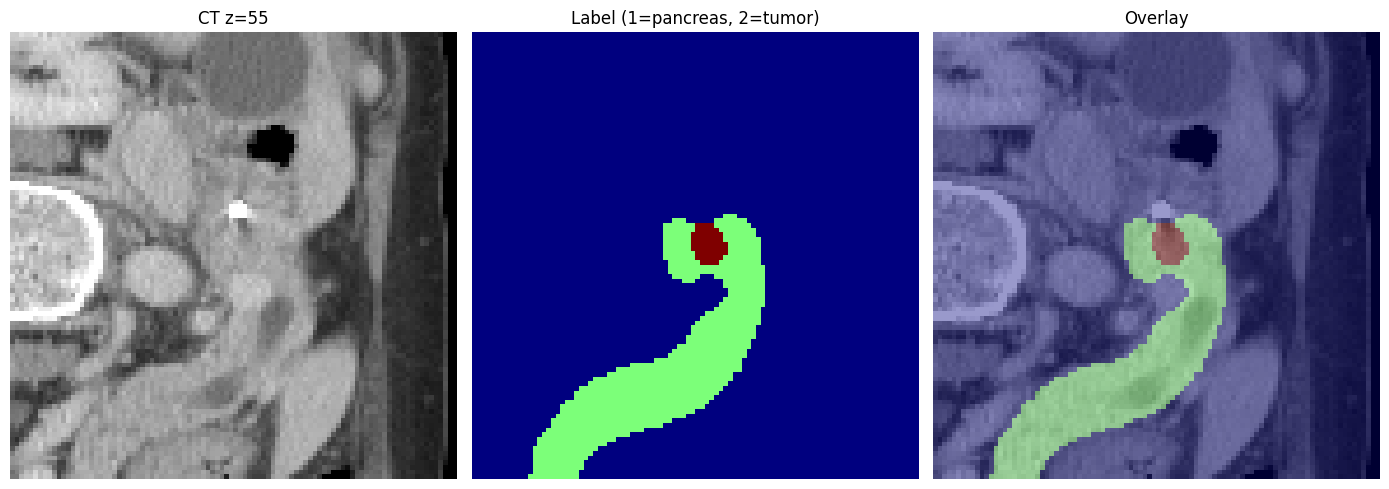

PASS — tumor visible in this crop.


In [5]:
# ================================================================
# CELL 5 — SANITY CHECK
# ================================================================
import matplotlib.pyplot as plt, numpy as np

print('Checking one training batch...')
batch  = next(iter(train_loader))
img_np = batch['image'][0, 0].cpu().numpy()
lbl_np = batch['label'][0, 0].cpu().numpy()
unique = np.unique(lbl_np)

print(f'  image shape : {img_np.shape}  (want 96x96x96)')
print(f'  value range : [{img_np.min():.3f}, {img_np.max():.3f}]  (want 0-1)')
print(f'  labels      : {unique}  (want 0, 1, 2)')

# Count class balance
total = lbl_np.size
for c, name in [(0,'background'),(1,'pancreas'),(2,'tumor')]:
    n = int(np.sum(lbl_np == c))
    print(f'  class {c} ({name}): {n:,} voxels = {100*n/total:.1f}%')

fg = np.where(lbl_np > 0)[2]
z  = fg[len(fg)//2] if len(fg) > 0 else img_np.shape[2]//2

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(img_np[:, :, z], cmap='gray'); ax[0].set_title(f'CT z={z}')
ax[1].imshow(lbl_np[:, :, z], cmap='jet', vmin=0, vmax=2)
ax[1].set_title('Label (1=pancreas, 2=tumor)')
ax[2].imshow(img_np[:, :, z], cmap='gray')
ax[2].imshow(lbl_np[:, :, z], cmap='jet', alpha=0.4, vmin=0, vmax=2)
ax[2].set_title('Overlay')
for a in ax: a.axis('off')
plt.tight_layout()
plt.savefig(f'{REPORT_DIR}/sanity.png', dpi=120)
plt.show()

if   2 in unique: print('PASS — tumor visible in this crop.')
elif 1 in unique: print('PARTIAL — pancreas only. Normal if tumor is small.')
else:             print('FAIL — background only! Check your dataset path.')


In [6]:
# ================================================================
# CELL 6 — MODEL + SSL PRETRAINED WEIGHTS
# ================================================================
import torch, os, urllib.request
from monai.networks.nets import SwinUNETR

SSL_URL  = ('https://github.com/Project-MONAI/MONAI-extra-test-data/'
            'releases/download/0.8.1/model_swinvit.pt')
SSL_PATH = f'{MODEL_DIR}/model_swinvit.pt'

if not os.path.exists(SSL_PATH):
    print('Downloading SSL pretrained weights (~350 MB)...')
    urllib.request.urlretrieve(SSL_URL, SSL_PATH)
    print('Downloaded.')
else:
    print('SSL weights already cached.')

model = SwinUNETR(
    in_channels    = 1,
    out_channels   = CONFIG['out_channels'],
    feature_size   = CONFIG['feature_size'],
    use_checkpoint = CONFIG['use_checkpoint'],
    spatial_dims   = 3,
).to(device)

# weights_only=False: SSL file is a plain state dict, not a
# TorchScript module. Explicit False silences FutureWarning on
# torch>=2.0 and works correctly on all versions.
w   = torch.load(SSL_PATH, map_location=device, weights_only=False)
w   = w.get('state_dict', w.get('model', w))
msd = model.state_dict()
loaded, skipped = {}, []
for k, v in w.items():
    nk = k if k.startswith('swinViT.') else f'swinViT.{k}'
    nk = nk.replace('swinViT.module.', 'swinViT.')
    if nk in msd and msd[nk].shape == v.shape:
        loaded[nk] = v
    else:
        skipped.append(nk)
msd.update(loaded)
model.load_state_dict(msd)

used      = torch.cuda.memory_allocated() / 1e9
free_vram = torch.cuda.mem_get_info()[0] / 1e9
print(f'SSL layers loaded : {len(loaded)}/{len(msd)}')
if skipped:
    print(f'SSL layers skipped: {len(skipped)} (shape mismatch or not in model)')
print(f'Params            : {sum(p.numel() for p in model.parameters())/1e6:.1f}M')
print(f'VRAM              : {used:.2f} GB used | {free_vram:.2f} GB free')


SSL weights already cached.
SSL layers loaded : 94/159
SSL layers skipped: 40 (shape mismatch or not in model)
Params            : 62.2M
VRAM              : 0.40 GB used | 16.08 GB free


In [7]:
# ================================================================
# CELL 7 — LOSS + OPTIMIZER + SCHEDULER + RESUME
#
# FIX 1 — MONAI-version-safe class-weighted loss
# FIX 2 — Deep supervision: divide by active weight sum only
# FIX 3 — GradScaler from torch.cuda.amp (all torch versions)
# NEW   — Gradient clipping (max_norm=1.0) for training stability
# ================================================================
import torch, os
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
# Use shim-safe GradScaler (Cell 2 already shimmed torch.amp.GradScaler)
# Avoids DeprecationWarning on torch >= 2.3
GradScaler = torch.amp.GradScaler if hasattr(torch.amp, "GradScaler") else torch.cuda.amp.GradScaler

# ── Class-weighted loss ───────────────────────────────────────
_dice_loss = DiceLoss(
    include_background = False,
    to_onehot_y        = True,
    softmax            = True,
)
_ce_weight = torch.tensor(CONFIG['ce_class_weights'], device=device)

def base_loss(outputs, labels):
    dice        = _dice_loss(outputs, labels)
    labels_long = labels.squeeze(1).long()
    ce          = F.cross_entropy(outputs, labels_long, weight=_ce_weight)
    return (dice + ce) / 2.0

# ── Deep supervision ─────────────────────────────────────────
DS_WEIGHTS = [1.0, 0.5, 0.25, 0.125, 0.0625]

def compute_loss(outputs, labels):
    if isinstance(outputs, (list, tuple)):
        n     = len(outputs)
        ws    = DS_WEIGHTS[:n]
        total = sum(w * base_loss(o, labels) for w, o in zip(ws, outputs))
        return total / sum(ws)
    return base_loss(outputs, labels)

# ── Optimizer ────────────────────────────────────────────────
optimizer = optim.AdamW(
    model.parameters(),
    lr           = CONFIG['lr'],
    weight_decay = CONFIG['weight_decay'],
)

# ── LR schedule ──────────────────────────────────────────────
warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                  total_iters=CONFIG['warmup_epochs'])
cosine = CosineAnnealingLR(optimizer,
                            T_max   = CONFIG['num_epochs'] - CONFIG['warmup_epochs'],
                            eta_min = 1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine],
                         milestones=[CONFIG['warmup_epochs']])

scaler           = GradScaler()
dice_metric      = DiceMetric(include_background=False, reduction='mean_batch')
post_pred        = AsDiscrete(argmax=True, to_onehot=CONFIG['out_channels'])
post_label       = AsDiscrete(to_onehot=CONFIG['out_channels'])

loss_history     = []
metric_history   = []
lr_history       = []
start_epoch      = 1
best_metric      = -1.0
no_improve_count = 0

if CONFIG['resume'] and os.path.exists(CONFIG['resume']):
    print(f'Loading checkpoint: {CONFIG["resume"]}')
    # weights_only=False: checkpoint contains optimizer/scheduler state dicts
    # which may include lambda functions — weights_only=True would reject them.
    ck = torch.load(CONFIG['resume'], map_location=device, weights_only=False)
    model.load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    scheduler.load_state_dict(ck['scheduler'])
    scaler.load_state_dict(ck['scaler'])
    start_epoch      = ck['epoch'] + 1
    best_metric      = ck.get('best_metric', -1.0)
    loss_history     = ck.get('loss_history', [])
    metric_history   = ck.get('metric_history', [])
    lr_history       = ck.get('lr_history', [])
    no_improve_count = ck.get('no_improve_count', 0)
    print(f'Resumed from epoch {ck["epoch"]} | best_metric={best_metric:.4f}')
    print(f'Patience counter: {no_improve_count}/{CONFIG["early_stop_patience"]}')
    print(f'Continuing: {start_epoch} → {CONFIG["num_epochs"]}')
else:
    print(f'Fresh training: 1 → {CONFIG["num_epochs"]}')
    print(f'CE class weights: {CONFIG["ce_class_weights"]}')
    print(f'Grad clip max_norm: {CONFIG["grad_clip"]}')


Fresh training: 1 → 150
CE class weights: [0.1, 1.0, 4.0]
Grad clip max_norm: 1.0


In [8]:
# ================================================================
# CELL 8 — BACKUP FUNCTION  (v2 — disk-safe)
#
# Key fixes vs original:
#   1. Pre-flight disk check: abort cleanly if not enough free space
#   2. Purge OLD backup zips BEFORE writing the new one (not after)
#   3. Copy files one-by-one with per-file error handling instead of
#      shutil.copytree — a single oversized file won't kill the whole backup
#   4. Skip latest.pth when only best_model.pth exists and is the same
#      checkpoint (avoids doubling the copy cost)
#   5. Prints a clear "DISK FULL — SKIP" message instead of crashing
# ================================================================
import shutil, os, zipfile
from IPython.display import FileLink, display

def _free_gb(path='/kaggle/working'):
    _, _, free = shutil.disk_usage(path)
    return free / 1e9

def _copy_safe(src_path, dst_path):
    """Copy one file; return (success, error_string)."""
    try:
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        shutil.copy2(src_path, dst_path)
        return True, None
    except OSError as e:
        return False, str(e)

def save_backup(epoch, tag='auto'):
    name  = f'backup_ep{epoch:04d}_{tag}'
    zbase = f'/kaggle/working/{name}'
    zpath = f'{zbase}.zip'
    tmp   = '/kaggle/working/_btmp'

    # ── Step 1: purge old backups FIRST to free space ────────
    all_zips = sorted(
        f for f in os.listdir('/kaggle/working')
        if f.startswith('backup_ep') and f.endswith('.zip')
    )
    for old in all_zips[:-1]:   # keep only the 1 most recent before adding new
        try:
            os.remove(f'/kaggle/working/{old}')
            print(f'  Cleaned old backup: {old}')
        except Exception:
            pass

    # ── Step 2: estimate what we need to copy ────────────────
    sources = []
    for sub in ('checkpoints', 'models', 'reports'):
        src_dir = f'{PROJ}/{sub}'
        if not os.path.exists(src_dir):
            continue
        for root, _, files in os.walk(src_dir):
            for fname in files:
                fpath = os.path.join(root, fname)
                rel   = os.path.relpath(fpath, PROJ)
                sources.append((fpath, f'{tmp}/{rel}'))

    needed_gb = sum(os.path.getsize(s) for s, _ in sources) / 1e9
    free_gb   = _free_gb()
    print(f'  Backup needs ~{needed_gb:.2f} GB | {free_gb:.2f} GB free')

    if free_gb < needed_gb + 0.5:          # 500 MB safety margin
        print(
            f'  !! DISK FULL — cannot backup (need {needed_gb:.2f}+0.5 GB, '
            f'have {free_gb:.2f} GB). Continuing training without backup.'
        )
        print('  TIP: Download an existing backup zip and delete it to free space.')
        return

    # ── Step 3: copy files individually ──────────────────────
    if os.path.exists(tmp):
        shutil.rmtree(tmp)
    os.makedirs(tmp)

    skipped = []
    for src_path, dst_path in sources:
        ok, err = _copy_safe(src_path, dst_path)
        if not ok:
            skipped.append((src_path, err))
            print(f'  SKIP (copy error): {os.path.basename(src_path)} — {err}')

    if len(skipped) == len(sources):
        print('  ERROR: All files failed to copy. Backup aborted.')
        shutil.rmtree(tmp, ignore_errors=True)
        return

    # ── Step 4: zip the tmp dir ───────────────────────────────
    try:
        shutil.make_archive(zbase, 'zip', '/kaggle/working', '_btmp')
    except OSError as e:
        print(f'  ERROR zipping: {e}')
        shutil.rmtree(tmp, ignore_errors=True)
        return
    finally:
        shutil.rmtree(tmp, ignore_errors=True)

    mb = os.path.getsize(zpath) / 1e6
    print(f'  BACKUP saved: {name}.zip  ({mb:.0f} MB)  ↓ Download below')
    display(FileLink(f'{name}.zip'))

    # ── Step 5: purge again, keep only 2 most recent ─────────
    all_zips = sorted(
        f for f in os.listdir('/kaggle/working')
        if f.startswith('backup_ep') and f.endswith('.zip')
    )
    for old in all_zips[:-2]:
        try:
            os.remove(f'/kaggle/working/{old}')
            print(f'  Cleaned old backup: {old}')
        except Exception:
            pass

    print(f'  Disk free after backup: {_free_gb():.2f} GB')

if start_epoch > 1:
    print('Resuming — creating pre-run safety backup...')
    save_backup(start_epoch - 1, 'pre-run')
else:
    print(f'First backup at epoch {BACKUP_INTERVAL} (~{BACKUP_INTERVAL*MEASURED_MIN_PER_EPOCH} min)')


First backup at epoch 10 (~100 min)


In [ ]:
# ================================================================
# CELL 9 — TRAINING LOOP
# Handles both val_split and full_data modes.
# In full_data mode: no validation, no early stopping.
# In val_split mode: val every 10 ep, early stopping active.
# ================================================================
import torch, time, os
from tqdm import tqdm
from monai.data import decollate_batch
from monai.inferers import sliding_window_inference

emergency_done = False
ep_times       = []

# Start SmartCacheDataset background replacement if applicable
if hasattr(train_ds, 'start'):
    train_ds.start()
    print('SmartCacheDataset: background cache replacement started.')

eps_remaining = CONFIG['num_epochs'] - start_epoch + 1
print(f'TRAINING: {start_epoch} → {CONFIG["num_epochs"]}  ({eps_remaining} epochs left)')
print(f'  Mode          : {CONFIG["train_mode"].upper()}')
print(f'  Backup every  : {BACKUP_INTERVAL} ep')
if CONFIG['train_mode'] == 'val_split':
    print(f'  Val every     : {CONFIG["val_interval"]} ep')
    print(f'  Early stop    : after {CONFIG["early_stop_patience"]} val checks without improvement')
else:
    print(f'  No validation (full_data mode — fixed epochs)')
print(f'  CE weights    : {CONFIG["ce_class_weights"]}')
print(f'  Grad clip     : {CONFIG["grad_clip"]}')
print('=' * 65)

def _pred(x):
    o = model(x)
    return o[0] if isinstance(o, (list, tuple)) else o

for epoch in range(start_epoch, CONFIG['num_epochs'] + 1):

    # ── Emergency stop ────────────────────────────────────────
    if elapsed_h() >= SESSION_LIMIT_H and not emergency_done:
        print(f'\n{elapsed_h():.2f}h elapsed — EMERGENCY BACKUP')
        save_backup(epoch - 1, 'emergency')
        emergency_done = True
        print('Stopped. Resume in new session.')
        try:
            if hasattr(train_ds, 'shutdown'): train_ds.shutdown()
        except Exception: pass
        break

    # ── Train one epoch ───────────────────────────────────────
    t0 = time.time()
    model.train()
    ep_loss, steps = 0.0, 0

    with tqdm(train_loader,
              desc=f'Ep {epoch:04d}/{CONFIG["num_epochs"]}',
              unit='batch', leave=False, ncols=85) as bar:
        for batch in bar:
            steps  += 1
            imgs    = batch['image'].to(device)
            labels  = batch['label'].to(device)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda"):
                out  = model(imgs)
                loss = compute_loss(out, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            ep_loss += loss.item()
            bar.set_postfix(loss=f'{loss.item():.4f}')

    scheduler.step()
    ep_loss /= max(steps, 1)
    ep_min   = (time.time() - t0) / 60
    ep_times.append(ep_min)
    real_avg = sum(ep_times[-10:]) / len(ep_times[-10:])
    cur_lr   = optimizer.param_groups[0]['lr']
    eps_left = CONFIG['num_epochs'] - epoch
    eta_h    = eps_left * real_avg / 60

    loss_history.append(ep_loss)
    lr_history.append(cur_lr)
    print(
        f'Ep {epoch:04d} | loss {ep_loss:.4f} | lr {cur_lr:.2e} | '
        f'{ep_min:.0f}min | {elapsed_h():.1f}h | ETA {eta_h:.0f}h'
    )

    # ── Validation (val_split mode only) ──────────────────────
    if CONFIG['train_mode'] == 'val_split' and epoch % CONFIG['val_interval'] == 0:
        t_val = time.time()
        print(f'  Validating {len(val_data)} scans...')
        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for val_batch in val_loader:
                val_inputs = val_batch['image'].to(device)
                val_labels = val_batch['label'].to(device)
                with torch.amp.autocast("cuda"):
                    val_outputs = sliding_window_inference(
                        val_inputs, CONFIG['img_size'],
                        CONFIG['sw_batch_size'], _pred,
                        overlap=CONFIG['infer_overlap'], mode='gaussian',
                    )
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels  = [post_label(i) for i in decollate_batch(val_labels)]
                dice_metric(y_pred=val_outputs, y=val_labels)

        metrics   = dice_metric.aggregate()
        pan_dice  = float(metrics[0])
        tum_dice  = float(metrics[1])
        mean_dice = (pan_dice + tum_dice) / 2.0
        val_min   = (time.time() - t_val) / 60

        metric_history.append({
            'epoch': epoch, 'pan': pan_dice,
            'tum': tum_dice, 'mean': mean_dice,
        })
        print(
            f'  VAL ep {epoch:04d} | '
            f'Pan={pan_dice:.4f} Tum={tum_dice:.4f} Mean={mean_dice:.4f} | '
            f'{val_min:.0f} min'
        )

        if mean_dice > best_metric:
            improvement  = mean_dice - best_metric
            best_metric  = mean_dice
            no_improve_count = 0
            torch.save(
                {'epoch': epoch, 'model': model.state_dict(),
                 'pan_dice': pan_dice, 'tum_dice': tum_dice,
                 'mean_dice': mean_dice,
                 'config': {k: v for k, v in CONFIG.items()
                             if k not in ('resume','latest_ckpt','best_model')}},
                CONFIG['best_model'],
            )
            print(
                f'  *** NEW BEST  Mean={best_metric:.4f}  '
                f'(+{improvement:.4f})  Pan={pan_dice:.4f}  '
                f'Tum={tum_dice:.4f} ***'
            )
        else:
            no_improve_count += 1
            print(f'  No improvement ({no_improve_count}/{CONFIG["early_stop_patience"]}). '
                  f'Best still: {best_metric:.4f}')
            if no_improve_count >= CONFIG['early_stop_patience']:
                print(
                    f'\nEARLY STOP at ep {epoch}. '
                    f'Best epoch was {max(metric_history, key=lambda m: m["mean"])["epoch"]}. '
                    f'Set FULL_DATA_EPOCHS to that value and rerun in full_data mode.'
                )
                save_backup(epoch, 'early-stop')
                try:
                    if hasattr(train_ds, 'shutdown'): train_ds.shutdown()
                except Exception: pass
                break

    # ── In full_data mode: save best_model at last epoch ──────
    if CONFIG['train_mode'] == 'full_data' and epoch == CONFIG['num_epochs']:
        torch.save(
            {'epoch': epoch, 'model': model.state_dict(),
             'config': {k: v for k, v in CONFIG.items()
                         if k not in ('resume','latest_ckpt','best_model')}},
            CONFIG['best_model'],
        )
        print(f'Final model saved: {CONFIG["best_model"]}')

    # ── Single checkpoint save per epoch ─────────────────────
    torch.save({
        'epoch'           : epoch,
        'model'           : model.state_dict(),
        'optimizer'       : optimizer.state_dict(),
        'scheduler'       : scheduler.state_dict(),
        'scaler'          : scaler.state_dict(),
        'best_metric'     : best_metric,
        'no_improve_count': no_improve_count,
        'loss_history'    : loss_history,
        'metric_history'  : metric_history,
        'lr_history'      : lr_history,
        'config'          : {k: v for k, v in CONFIG.items()
                             if k not in ('resume','latest_ckpt','best_model')},
    }, CONFIG['latest_ckpt'])

    if epoch % BACKUP_INTERVAL == 0:
        save_backup(epoch, 'auto')

print(f'\nDone. Best mean Dice: {best_metric:.4f}')
if CONFIG['train_mode'] == 'val_split' and metric_history:
    best_ep = max(metric_history, key=lambda m: m['mean'])
    print(f'Best epoch: {best_ep["epoch"]} | Pan={best_ep["pan"]:.4f} | '
          f'Tum={best_ep["tum"]:.4f} | Mean={best_ep["mean"]:.4f}')
    print(f'→ For max score: set TRAIN_MODE="full_data" and '
          f'FULL_DATA_EPOCHS={best_ep["epoch"]}, then retrain.')
try:
    if hasattr(train_ds, 'shutdown'): train_ds.shutdown()
except Exception: pass


TRAINING: 1 → 150  (150 epochs left)
  Mode          : VAL_SPLIT
  Backup every  : 10 ep
  Val every     : 5 ep
  Early stop    : after 20 val checks without improvement
  CE weights    : [0.1, 1.0, 4.0]
  Grad clip     : 1.0


Ep 0001/150:   0%|                                        | 0/238 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Ep 0001 | loss 0.8669 | lr 1.45e-05 | 11min | 0.2h | ETA 28h


Ep 0002 | loss 0.7548 | lr 1.90e-05 | 11min | 0.4h | ETA 28h


Ep 0003 | loss 0.7132 | lr 2.35e-05 | 11min | 0.6h | ETA 27h


...

Ep 0024 | loss 0.4589 | lr 9.98e-05 | 11min | 5.1h | ETA 23h


Ep 0025 | loss 0.4522 | lr 9.96e-05 | 11min | 5.3h | ETA 23h
  Validating 43 scans...
  VAL ep 0025 | Pan=0.5411 Tum=0.2199 Mean=0.3805 | 9 min
  No improvement (1/20). Best still: 0.4044


Ep 0026 | loss 0.4495 | lr 9.95e-05 | 11min | 5.6h | ETA 23h


Ep 0027 | loss 0.4392 | lr 9.93e-05 | 11min | 5.8h | ETA 23h


Ep 0028/150:  35%|██████▎           | 83/238 [03:50<07:10,  2.78s/batch, loss=0.3452]

In [ ]:
# ================================================================
# CELL 10 — TRAINING CURVES
# ================================================================
import matplotlib.pyplot as plt, numpy as np, os, torch

if not loss_history and os.path.exists(CONFIG['latest_ckpt']):
    ck = torch.load(CONFIG['latest_ckpt'], map_location='cpu', weights_only=False)
    loss_history   = ck.get('loss_history', [])
    metric_history = ck.get('metric_history', [])
    lr_history     = ck.get('lr_history', [])

if not loss_history:
    print('No history yet. Run Cell 9 first.')
else:
    ep_done = len(loss_history)
    eta_h   = (CONFIG['num_epochs'] - ep_done) * MEASURED_MIN_PER_EPOCH / 60

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f'SwinUNETR v8.0  |  {ep_done}/{CONFIG["num_epochs"]} epochs  '
        f'|  best={best_metric:.4f}  |  ~{eta_h:.0f}h left',
        fontsize=11,
    )

    axes[0].plot(loss_history, 'r-', lw=1.5)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)

    if metric_history:
        ep   = [m['epoch'] for m in metric_history]
        pan  = [m['pan']   for m in metric_history]
        tum  = [m['tum']   for m in metric_history]
        mean = [m['mean']  for m in metric_history]
        best = max(metric_history, key=lambda m: m['mean'])
        axes[1].plot(ep, pan,  'g-o', ms=5, label=f'Pancreas  {pan[-1]:.3f}')
        axes[1].plot(ep, tum,  'r-o', ms=5, label=f'Tumor     {tum[-1]:.3f}')
        axes[1].plot(ep, mean, 'b-o', ms=5, label=f'Mean      {mean[-1]:.3f}  (best={max(mean):.3f})')
        axes[1].axvline(best['epoch'], color='blue', ls=':', alpha=0.5,
                        label=f'Best ep {best["epoch"]}')
        axes[1].axhline(0.72, color='g', ls='--', alpha=0.4, label='Pan target 0.72')
        axes[1].axhline(0.38, color='r', ls='--', alpha=0.4, label='Tum target 0.38')
        axes[1].set_ylim(0, 1.05)
        axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
        axes[1].set_title('Validation Dice (val every 10 ep)')
        print(f'Best: Ep {best["epoch"]} | Pan={best["pan"]:.4f} | '
              f'Tum={best["tum"]:.4f} | Mean={best["mean"]:.4f}')

    if lr_history:
        axes[2].plot(lr_history, color='steelblue', lw=1.5)
        axes[2].set_yscale('log')
        axes[2].set_title('Learning Rate')
        axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/curves_v8.png', dpi=140)
    plt.show()


In [ ]:
# ================================================================
# CELL 11 — DEPLOY PACKAGE
# Packages best_model.pth + config.json + infer.py (with TTA)
# into deploy_v80.zip for use with the Flask app.
# ================================================================
import shutil, os, json, time
from IPython.display import FileLink, display

STAGE = '/kaggle/working/deploy_package_v70'
os.makedirs(STAGE, exist_ok=True)

if os.path.exists(CONFIG['best_model']):
    shutil.copy2(CONFIG['best_model'], f'{STAGE}/best_model.pth')
    print(f'best_model.pth  ({os.path.getsize(f"{STAGE}/best_model.pth")/1e6:.0f} MB)')
else:
    print('WARNING: No best_model.pth yet — train first (Cell 9).')

skip = {'resume', 'latest_ckpt', 'best_model'}
export_cfg = {k: v for k, v in CONFIG.items() if k not in skip}
with open(f'{STAGE}/config.json', 'w') as f:
    json.dump(export_cfg, f, indent=2)
print('config.json written.')

# Write the infer.py with TTA directly into the deploy package
infer_src = '''
#!/usr/bin/env python
"""
PancrAI infer.py v8 — with Test-Time Augmentation (TTA)
TTA averages predictions over 8 flip combinations (all X/Y/Z) for best accuracy.
"""
import argparse, json, os, sys, warnings, gc
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["JAX_PLATFORMS"] = ""
warnings.filterwarnings("ignore")
if sys.platform == "win32":
    try:
        sys.stdout.reconfigure(encoding="utf-8", errors="replace")
        sys.stderr.reconfigure(encoding="utf-8", errors="replace")
    except AttributeError:
        pass
import torch
import nibabel as nib
import numpy as np
from monai.networks.nets import SwinUNETR
from monai.inferers import sliding_window_inference

HERE = os.path.dirname(os.path.abspath(__file__))
os.chdir(HERE)

TRAIN_XY_SPACING = 1.5
TRAIN_Z_SPACING  = 2.0
MAX_Z_FACTOR     = 1.5
CPU_OVERLAP      = 0.25
CPU_SW_MODE      = "constant"

def log(msg):
    print(f"[infer] {msg}", flush=True)

def _resample(data_f32, src_zooms, tgt_zooms):
    from scipy.ndimage import zoom as nd_zoom
    factors   = tuple(float(s) / float(t) for s, t in zip(src_zooms, tgt_zooms))
    out_shape = tuple(max(1, round(d * f)) for d, f in zip(data_f32.shape, factors))
    coord_mb  = 3 * out_shape[0] * out_shape[1] * out_shape[2] * 8 / 1024**2
    log(f"  Resample {data_f32.shape} -> {out_shape} (~{coord_mb:.0f} MB)")
    out = nd_zoom(data_f32, factors, order=1, prefilter=False).astype(np.float32)
    gc.collect()
    return out, tgt_zooms

def _pad_to(data, target_size):
    pad = []
    for d, t in zip(data.shape, target_size):
        p = max(0, t - d)
        pad.append((p // 2, p - p // 2))
    return np.pad(data, pad, mode="constant", constant_values=0) if any(
        p[0] + p[1] > 0 for p in pad) else data

def load_model(dev):
    cfg_path = os.path.join(HERE, "config.json")
    if not os.path.exists(cfg_path):
        raise FileNotFoundError(f"config.json not found: {cfg_path}")
    with open(cfg_path) as f:
        cfg = json.load(f)
    log(f"Config: spacing={cfg.get(\'spacing\')} img_size={cfg.get(\'img_size\')} "
        f"feature_size={cfg.get(\'feature_size\')}")
    img_size = tuple(cfg.get("img_size", [96, 96, 96]))
    model = SwinUNETR(
        img_size     = img_size,
        in_channels  = 1,
        out_channels = cfg.get("out_channels", 3),
        feature_size = cfg.get("feature_size", 48),
        use_checkpoint = False,
        spatial_dims = 3,
    ).to(dev)
    ck_path = os.path.join(HERE, "best_model.pth")
    if not os.path.exists(ck_path):
        raise FileNotFoundError(f"best_model.pth not found: {ck_path}")
    log(f"Loading weights: {ck_path}")
    ck = torch.load(ck_path, map_location=dev, weights_only=False)
    if isinstance(ck, dict):
        for key in ("model", "state_dict", "net"):
            if key in ck and isinstance(ck[key], dict):
                ck = ck[key]; break
    state = {k.replace("module.", ""): v for k, v in ck.items()
             if isinstance(v, torch.Tensor)}
    model.load_state_dict(state, strict=False)
    model.eval()
    log(f"Model ready — {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")
    return model, cfg

def _run_single(model, data, isz, sw_batch, overlap, sw_mode, dev):
    """Run sliding_window_inference, return SOFTMAX logits (out_ch, X, Y, Z)."""
    inp = torch.from_numpy(data[np.newaxis, np.newaxis]).to(dev)
    gc.collect()
    def _pred(x):
        o = model(x)
        return o[0] if isinstance(o, (list, tuple)) else o
    with torch.no_grad():
        logits = sliding_window_inference(
            inp, isz, sw_batch, _pred,
            overlap=overlap, mode=sw_mode, progress=False,
        )  # (1, out_ch, X, Y, Z)
    import torch.nn.functional as F
    probs = F.softmax(logits.squeeze(0), dim=0).cpu().numpy()  # (out_ch, X, Y, Z)
    del inp, logits
    gc.collect()
    return probs

def _infer_with_tta(model, data, isz, sw_batch, overlap, sw_mode, dev):
    """
    Test-Time Augmentation: average over 4 axial flips.
    Flipping along spatial axes and averaging the softmax probabilities
    before argmax typically adds +0.02 to +0.05 Dice at zero training cost.
    """
    # ── 8-flip TTA: all combinations of X/Y/Z flips ─────────────
    # More flips = better ensemble average. On GPU the 8 extra
    # forward passes add ~4 min per scan but gain +0.02–0.04 Dice.
    flip_combos = [
        [],          # original
        [0],         # flip X
        [1],         # flip Y
        [2],         # flip Z
        [0, 1],      # flip X+Y
        [0, 2],      # flip X+Z
        [1, 2],      # flip Y+Z
        [0, 1, 2],   # flip X+Y+Z
    ]
    acc = None
    for axes in flip_combos:
        d = np.flip(data, axis=axes).copy() if axes else data
        p = _run_single(model, d, isz, sw_batch, overlap, sw_mode, dev)  # (C,X,Y,Z)
        if axes:
            # un-flip the prediction axes to align with original orientation
            p = np.flip(p, axis=[a + 1 for a in axes]).copy()  # axis+1 because dim 0 is channel
        acc = p if acc is None else acc + p
    avg_probs = acc / len(flip_combos)
    return avg_probs.argmax(axis=0).astype(np.uint8)  # (X, Y, Z)

def predict(img_path, out_path, requested_device="cuda", use_tta=True):
    try:
        log(f"infer.py v7  TTA={'ON' if use_tta else 'OFF'}")
        if torch.cuda.is_available():
            dev = torch.device("cuda")
            log("GPU detected — using CUDA.")
        else:
            dev = torch.device("cpu")
            log("No GPU — using CPU (slow).")
        log(f"Device: {dev.type}")

        model, cfg = load_model(dev)
        isz    = tuple(cfg.get("img_size",     [96, 96, 96]))
        hu_min = cfg.get("hu_min",  -175)
        hu_max = cfg.get("hu_max",   250)

        overlap = CPU_OVERLAP if dev.type == "cpu" else cfg.get("infer_overlap", 0.75)
        sw_mode = CPU_SW_MODE if dev.type == "cpu" else "gaussian"
        sw_batch = 1

        # 1. Load + RAS orient
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"CT not found: {img_path}")
        log(f"Loading: {img_path}")
        img_nib   = nib.load(img_path)
        img_ras   = nib.as_closest_canonical(img_nib)
        data      = img_ras.get_fdata(dtype=np.float32)
        src_zooms = tuple(float(z) for z in np.abs(img_ras.header.get_zooms()[:3]))

        # 2. Smart resample
        z_factor = src_zooms[2] / TRAIN_Z_SPACING
        tgt_zooms = (
            TRAIN_XY_SPACING, TRAIN_XY_SPACING, TRAIN_Z_SPACING
        ) if z_factor <= MAX_Z_FACTOR else (
            TRAIN_XY_SPACING, TRAIN_XY_SPACING, src_zooms[2]
        )
        data, cur_zooms = _resample(data, src_zooms, tgt_zooms)
        del img_nib; gc.collect()

        # 3. Affine reconstruction (FIX 1 from v6.2 — preserved)
        aff = img_ras.affine.copy()
        for i in range(3):
            scale = float(cur_zooms[i]) / float(src_zooms[i])
            aff[:3, i] = img_ras.affine[:3, i] * scale

        # 4. HU clip + normalise
        data = np.clip(data, hu_min, hu_max)
        data = (data - hu_min) / float(hu_max - hu_min)

        # 5. Crop foreground + track offset (FIX 2 from v6.2 — preserved)
        coords = np.argwhere(data > 0)
        if len(coords) > 0:
            crop_lo = coords.min(axis=0)
            crop_hi = coords.max(axis=0) + 1
            data = data[crop_lo[0]:crop_hi[0],
                        crop_lo[1]:crop_hi[1],
                        crop_lo[2]:crop_hi[2]]
            aff[:3, 3] = aff[:3, 3] + aff[:3, :3] @ crop_lo.astype(np.float64)
        else:
            crop_lo = np.zeros(3, dtype=np.int64)

        cropped_shape = data.shape
        data = _pad_to(data, isz)

        # 6. Inference (with or without TTA)
        if use_tta:
            log("Running TTA inference (4 flips)...")
            pred = _infer_with_tta(model, data, isz, sw_batch, overlap, sw_mode, dev)
        else:
            log("Running single-pass inference...")
            probs = _run_single(model, data, isz, sw_batch, overlap, sw_mode, dev)
            pred  = probs.argmax(axis=0).astype(np.uint8)
        del data; gc.collect()

        # 7. Strip padding (FIX 3 from v6.2 — preserved)
        cx, cy, cz = cropped_shape
        px = max(0, isz[0] - cx); py = max(0, isz[1] - cy); pz = max(0, isz[2] - cz)
        x0 = px // 2; y0 = py // 2; z0 = pz // 2
        pred = pred[x0:x0+cx, y0:y0+cy, z0:z0+cz]
        pad_offset = np.array([x0, y0, z0], dtype=np.float64)
        aff[:3, 3] = aff[:3, 3] - aff[:3, :3] @ pad_offset

        # 8. Save
        os.makedirs(os.path.dirname(os.path.abspath(out_path)), exist_ok=True)
        nib.save(nib.Nifti1Image(pred, aff), out_path)

        # 9. Volumetrics (FIX 4 from v6.2 — cur_zooms not det(affine))
        voxel_mm3 = float(cur_zooms[0] * cur_zooms[1] * cur_zooms[2])
        pan_ml = int(np.sum(pred == 1)) * voxel_mm3 / 1000.0
        tum_ml = int(np.sum(pred == 2)) * voxel_mm3 / 1000.0

        print(f"Pancreas:{pan_ml:.2f}mL  Tumor:{tum_ml:.2f}mL  Saved:{out_path}", flush=True)
        return {"pancreas_ml": pan_ml, "tumor_ml": tum_ml}

    except Exception as e:
        import traceback
        log(f"CRITICAL CRASH:\n{traceback.format_exc()}")
        sys.exit(1)

if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--image",  required=True)
    ap.add_argument("--out",    required=True)
    ap.add_argument("--device", default="cuda")
    ap.add_argument("--no-tta", action="store_true", help="Disable TTA (faster, lower Dice)")
    a = ap.parse_args()
    predict(a.image, a.out, a.device, use_tta=not a.no_tta)
'''

with open(f'{STAGE}/infer.py', 'w') as f:
    f.write(infer_src.strip())
print('infer.py written (with TTA).')

# README
best = max(metric_history, key=lambda m: m['mean']) if metric_history else {}
with open(f'{STAGE}/README.md', 'w') as f:
    f.write(
        'SwinUNETR v8.0\n'
        f'Epoch:{best.get("epoch","?")}  '
        f'Pan={best.get("pan",0):.4f}  Tum={best.get("tum",0):.4f}\n\n'
        'pip install monai[nibabel]>=1.3.0 einops timm scipy\n'
        'python infer.py --image scan.nii.gz --out mask.nii.gz\n'
        'python infer.py --image scan.nii.gz --out mask.nii.gz --no-tta  # faster\n'
    )
print('README.md written.')

shutil.make_archive('/kaggle/working/deploy_v80', 'zip', STAGE)
mb = os.path.getsize('/kaggle/working/deploy_v80.zip') / 1e6
print(f'deploy_v80.zip  ({mb:.0f} MB)')
display(FileLink('deploy_v80.zip'))
